Objective: Explore and understand the heart disease dataset, identify the target variable, check data quality, and build a baseline understanding before modeling.

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

print(os.getcwd())


C:\Users\Gurnoor Singh\Desktop\AI-ML-HEART-DISEASE-PEDICTION


In [2]:
df = pd.read_csv("Data/heart-uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [4]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [5]:
df.shape

(920, 16)

In [6]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [7]:
df = df.drop(columns=["id","dataset"])

In [8]:
df["num"]=df["num"].apply(lambda x: 1 if x>0 else 0)

In [9]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [10]:
df["num"].value_counts()

num
1    509
0    411
Name: count, dtype: int64

In [11]:
df.isnull().sum()

age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [12]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]

for col in num_cols :
    df[col]=df[col].fillna(df[col].median())

In [13]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

for col in categorical_cols :
    df[col] = df[col].fillna(df[col].mode()[0])

df[categorical_cols] = df[categorical_cols].infer_objects(copy=False)

C:\Users\Gurnoor Singh\AppData\Local\Temp\ipykernel_30708\3672817551.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [14]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [15]:
df.dtypes

age           int64
sex          object
cp           object
trestbps    float64
chol        float64
fbs            bool
restecg      object
thalch      float64
exang          bool
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

In [16]:
encoded_df = pd.get_dummies(df,columns=["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"],drop_first=True)

In [17]:
encoded_df.head()

,age,trestbps,chol,thalch,oldpeak,ca,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,150.0,2.3,0.0,0,True,False,False,True,True,False,False,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,3.0,1,True,False,False,False,False,False,False,True,True,False,True,False
2,67,120.0,229.0,129.0,2.6,2.0,1,True,False,False,False,False,False,False,True,True,False,False,True
3,37,130.0,250.0,187.0,3.5,0.0,0,True,False,True,False,False,True,False,False,False,False,True,False
4,41,130.0,204.0,172.0,1.4,0.0,0,False,True,False,False,False,False,False,False,False,True,True,False


In [18]:
encoded_df.shape

(920, 19)

In [19]:
encoded_df.isnull().sum().sum()

np.int64(0)

In [20]:
x = encoded_df.drop("num",axis=1)
y = encoded_df["num"]

In [21]:
x.shape , y.shape

((920, 18), (920,))

In [22]:
print(df.dtypes[df.dtypes == "object"])


sex        object
cp         object
restecg    object
slope      object
thal       object
dtype: object


In [23]:
encoded_df = pd.get_dummies(df, drop_first=True)

In [24]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [25]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]


In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [27]:
print(x_train.dtypes)


age                         float64
trestbps                    float64
chol                        float64
thalch                      float64
oldpeak                     float64
ca                          float64
sex_Male                       bool
cp_atypical angina             bool
cp_non-anginal                 bool
cp_typical angina              bool
fbs_True                       bool
restecg_normal                 bool
restecg_st-t abnormality       bool
exang_True                     bool
slope_flat                     bool
slope_upsloping                bool
thal_normal                    bool
thal_reversable defect         bool
dtype: object


In [28]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [29]:
model.coef_ , model.intercept_

(array([[ 0.28154613,  0.06216299, -0.44495129, -0.27657425,  0.50026031,
          0.53151019,  1.12149199, -1.7762224 , -1.06224441, -0.9232223 ,
          0.36239082, -0.06236465,  0.28340908,  1.01051232,  0.71992648,
         -0.0832076 , -0.32291863,  0.34643887]]),
 array([-0.64773026]))

In [30]:
from sklearn.metrics import confusion_matrix , classification_report

y_pred = model.predict(x_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[65 17]
 [12 90]]
              precision    recall  f1-score   support

           0       0.84      0.79      0.82        82
           1       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [31]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)


rf_model = RandomForestClassifier (
    # n_estimators = 200,
    random_state =  42
)
param_grid_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring="roc_auc",   # better than raw accuracy for medical data
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(x_train_smote, y_train_smote)

# Fit on training data
# grid_rf.fit(x_train, y_train)

# Best tuned model
best_rf = grid_rf.best_estimator_

# Predict using the fitted tuned model
rf_pred = best_rf.predict(x_test)
rf_proba = best_rf.predict_proba(x_test)[:, 1]

# rf_pred = rf_model.predict(x_test)

print(confusion_matrix(y_test,rf_pred))
print(classification_report(y_test,rf_pred))

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
[[66 16]
 [12 90]]
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        82
           1       0.85      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



In [32]:
importances =best_rf.feature_importances_

feature_imp = pd.DataFrame({
    "feature" : x_train.columns,
    "importance" : importances
})

feature_imp = feature_imp.sort_values(by="importance",ascending=False)
print(feature_imp)

                     feature  importance
2                       chol    0.152705
0                        age    0.136634
3                     thalch    0.126380
4                    oldpeak    0.115920
13                exang_True    0.084249
1                   trestbps    0.078881
7         cp_atypical angina    0.070892
6                   sex_Male    0.036022
16               thal_normal    0.034355
8             cp_non-anginal    0.033024
5                         ca    0.023675
11            restecg_normal    0.018816
17    thal_reversable defect    0.017828
14                slope_flat    0.014517
10                  fbs_True    0.014466
15           slope_upsloping    0.014316
9          cp_typical angina    0.013722
12  restecg_st-t abnormality    0.013598


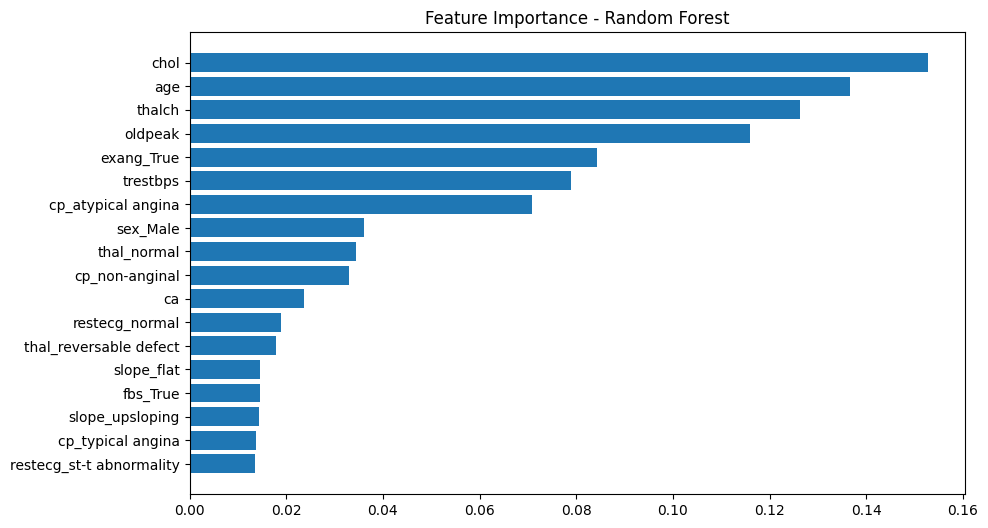

In [33]:
plt.figure(figsize=(10,6))
plt.barh(feature_imp["feature"], feature_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.show()

In [34]:
import pickle

with open("heart_disease_model.pkl","wb") as file:
    pickle.dump(rf_model,file)
print("model saved succesfully")

model saved succesfully


In [35]:
with open("scaler.pkl","wb") as file:
    pickle.dump(rf_model,file)
print("scaler saved succesfully")

scaler saved succesfully


In [36]:
import pickle

pickle.dump(rf_model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [37]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score
)
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")

In [38]:
xgb_base = xgb.XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)
 
xgb_base.fit(x_train, y_train)
xgb_base_pred = xgb_base.predict(x_test)
print(f"Accuracy : {accuracy_score(y_test, xgb_base_pred)*100:.2f}%")
print()
print(classification_report(y_test, xgb_base_pred))

Accuracy : 85.33%

              precision    recall  f1-score   support

           0       0.88      0.78      0.83        82
           1       0.84      0.91      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.86      0.85      0.85       184



In [39]:
!pip install imbalanced-learn

In [40]:
# param_grid = {
#     "n_estimators":      [100, 200, 300],
#     "max_depth":         [3, 4, 5],
#     "learning_rate":     [0.05, 0.1, 0.2],
#     "subsample":         [0.8, 1.0],
#     "colsample_bytree":  [0.8, 1.0],
# }

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1],
    "gamma": [0, 0.1, 0.3],
    "min_child_weight": [1, 3, 5]
}
 

xgb_model = xgb.XGBClassifier(
    random_state=42, 
    eval_metric="logloss",
    use_label_encoder=False
)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)
 
grid_search.fit(x_train, y_train)
 
print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_*100:.2f}%")

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits
Best parameters : {'colsample_bytree': 1, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 500, 'subsample': 0.8}
Best CV accuracy: 83.30%


In [41]:
best_xgb = grid_search.best_estimator_

xgb_pred  = best_xgb.predict(x_test)
xgb_proba = best_xgb.predict_proba(x_test)[:, 1]

print(f"Accuracy  : {accuracy_score(y_test, xgb_pred)*100:.2f}%")
print(f"ROC-AUC   : {roc_auc_score(y_test, xgb_proba)*100:.2f}%")
print()
print(classification_report(y_test, xgb_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

Accuracy  : 85.33%
ROC-AUC   : 90.41%

              precision    recall  f1-score   support

           0       0.84      0.83      0.83        82
           1       0.86      0.87      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184

Confusion Matrix:
[[68 14]
 [13 89]]


In [42]:
cv_scores = cross_val_score(best_xgb, x_train, y_train, cv=5, scoring="accuracy")

print(f"Scores per fold : {[round(s*100,2) for s in cv_scores]}")
print(f"Mean accuracy   : {cv_scores.mean()*100:.2f}%")
print(f"Std deviation   : {cv_scores.std()*100:.2f}%")

Scores per fold : [np.float64(82.82), np.float64(83.44), np.float64(76.69), np.float64(84.05), np.float64(85.8)]
Mean accuracy   : 82.56%
Std deviation   : 3.10%


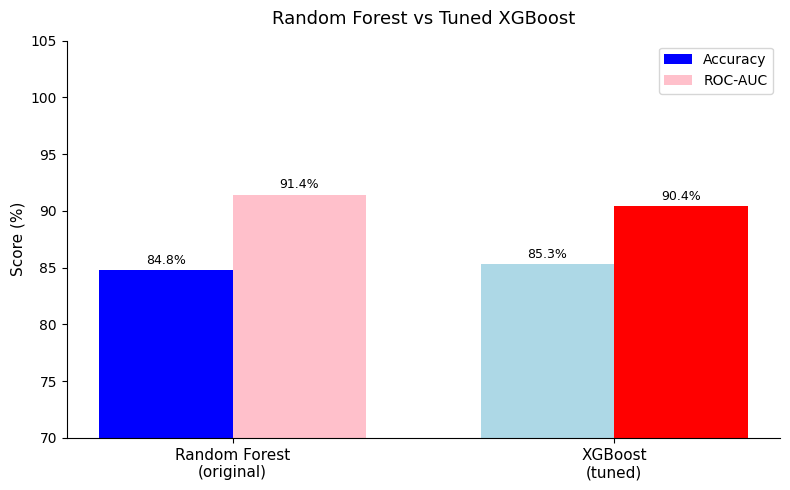

In [43]:
rf_pred = best_rf.predict(x_test)
rf_proba = best_rf.predict_proba(x_test)[:, 1]
 
models     = ["Random Forest\n(original)", "XGBoost\n(tuned)"]
accuracies = [
    accuracy_score(y_test, rf_pred)  * 100,
    accuracy_score(y_test, xgb_pred) * 100
]
aucs = [
    roc_auc_score(y_test, rf_proba)  * 100,
    roc_auc_score(y_test, xgb_proba) * 100
]
 
x_pos = [0, 1]
width = 0.35
 
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar([p - width/2 for p in x_pos], accuracies,
               width, label="Accuracy", color=["blue", "lightblue"])
bars2 = ax.bar([p + width/2 for p in x_pos], aucs,
               width, label="ROC-AUC",  color=["pink", "red"])
 
# Add value labels on top of each bar
for bar in bars1 + bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.1f}%",
        ha="center", va="bottom", fontsize=9
    )
 
ax.set_ylim(70, 105)
ax.set_xticks(x_pos)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel("Score (%)", fontsize=11)
ax.set_title("Random Forest vs Tuned XGBoost", fontsize=13, pad=12)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [44]:
xgb_importances = best_xgb.feature_importances_
feat_df_xgb = pd.DataFrame({
    "Feature":    x_train.columns,
    "Importance": xgb_importances
}).sort_values("Importance", ascending=False)
 
print("Top 10 features (XGBoost):")
print(feat_df_xgb.head(10).to_string(index=False))
 

Top 10 features (XGBoost):
           Feature  Importance
        exang_True    0.262207
cp_atypical angina    0.099199
    cp_non-anginal    0.079386
       thal_normal    0.064226
                ca    0.056960
 cp_typical angina    0.055905
          sex_Male    0.052066
              chol    0.045260
   slope_upsloping    0.038373
           oldpeak    0.038259


In [45]:
xgb_acc = accuracy_score(y_test, xgb_pred)
rf_acc  = accuracy_score(y_test, rf_pred)
 
if xgb_acc > rf_acc:
    print(f"\nXGBoost ({xgb_acc*100:.2f}%) beats Random Forest ({rf_acc*100:.2f}%)")
    print("Saving XGBoost as the new heart_disease_model.pkl ...")
 
    with open("heart_disease_model.pkl", "wb") as f:
        pickle.dump(best_xgb, f)
 
    print("heart_disease_model.pkl updated with XGBoost model")
    print("   scaler.pkl stays the same — preprocessing is unchanged")
else:
    print(f"\nRandom Forest ({rf_acc*100:.2f}%) still wins over XGBoost ({xgb_acc*100:.2f}%)")
    print("Keeping original heart_disease_model.pkl")
 


XGBoost (85.33%) beats Random Forest (84.78%)
Saving XGBoost as the new heart_disease_model.pkl ...
✅ heart_disease_model.pkl updated with XGBoost model
   scaler.pkl stays the same — preprocessing is unchanged


In [46]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)
import warnings
warnings.filterwarnings("ignore")
 

df_uci = pd.read_csv("Data/heart-uci.csv")
 

df_new = pd.read_csv("Data/heart_new.csv")
 
print("── Original UCI Dataset ──")
print(f"Shape: {df_uci.shape}")
print(df_uci.head(3))
 
print("\n── New Kaggle Dataset ──")
print(f"Shape: {df_new.shape}")
print(df_new.head(3))
print("\nNew dataset columns:", df_new.columns.tolist())
 

── Original UCI Dataset ──
Shape: (920, 16)
   id  age   sex    dataset              cp  trestbps   chol    fbs  \
0   1   63  Male  Cleveland  typical angina     145.0  233.0   True   
1   2   67  Male  Cleveland    asymptomatic     160.0  286.0  False   
2   3   67  Male  Cleveland    asymptomatic     120.0  229.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  

── New Kaggle Dataset ──
Shape: (918, 12)
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M          

In [47]:
print("New dataset unique values per column:")
for col in df_new.columns:
    print(f"  {col}: {df_new[col].unique()[:6]}")

New dataset unique values per column:
  Age: [40 49 37 48 54 39]
  Sex: ['M' 'F']
  ChestPainType: ['ATA' 'NAP' 'ASY' 'TA']
  RestingBP: [140 160 130 138 150 120]
  Cholesterol: [289 180 283 214 195 339]
  FastingBS: [0 1]
  RestingECG: ['Normal' 'ST' 'LVH']
  MaxHR: [172 156  98 108 122 170]
  ExerciseAngina: ['N' 'Y']
  Oldpeak: [0.  1.  1.5 2.  3.  4. ]
  ST_Slope: ['Up' 'Flat' 'Down']
  HeartDisease: [0 1]


In [48]:
df_new_clean = pd.DataFrame()
 
# rename
df_new_clean["age"]      = df_new["Age"]
df_new_clean["trestbps"] = df_new["RestingBP"]
df_new_clean["chol"]     = df_new["Cholesterol"]
df_new_clean["thalch"]   = df_new["MaxHR"]
df_new_clean["oldpeak"]  = df_new["Oldpeak"]
 
df_new_clean["sex"] = df_new["Sex"].map({"M": "Male", "F": "Female"})
 

cp_map = {
    "ASY": "asymptomatic",
    "ATA": "atypical angina",
    "NAP": "non-anginal",
    "TA":  "typical angina"
}
df_new_clean["cp"] = df_new["ChestPainType"].map(cp_map)

df_new_clean["fbs"] = df_new["FastingBS"].map({0: False, 1: True})

restecg_map = {
    "Normal": "normal",
    "ST":     "st-t abnormality",
    "LVH":    "lv hypertrophy"
}
df_new_clean["restecg"] = df_new["RestingECG"].map(restecg_map)

df_new_clean["exang"] = df_new["ExerciseAngina"].map({"Y": True, "N": False})

slope_map = {
    "Up":   "upsloping",
    "Flat": "flat",
    "Down": "downsloping"
}
df_new_clean["slope"] = df_new["ST_Slope"].map(slope_map)

df_new_clean["num"] = df_new["HeartDisease"]

df_new_clean["ca"]   = np.nan
df_new_clean["thal"] = np.nan
 
print("Cleaned new dataset:")
print(df_new_clean.head(3))
print(f"\nShape: {df_new_clean.shape}")
print(f"Missing values:\n{df_new_clean.isnull().sum()}")

Cleaned new dataset:
   age  trestbps  chol  thalch  oldpeak     sex               cp    fbs  \
0   40       140   289     172      0.0    Male  atypical angina  False   
1   49       160   180     156      1.0  Female      non-anginal  False   
2   37       130   283      98      0.0    Male  atypical angina  False   

            restecg  exang      slope  num  ca  thal  
0            normal  False  upsloping    0 NaN   NaN  
1            normal  False       flat    1 NaN   NaN  
2  st-t abnormality  False  upsloping    0 NaN   NaN  

Shape: (918, 14)
Missing values:
age           0
trestbps      0
chol          0
thalch        0
oldpeak       0
sex           0
cp            0
fbs           0
restecg       0
exang         0
slope         0
num           0
ca          918
thal        918
dtype: int64


In [49]:
df_uci_clean = df_uci.drop(columns=["id", "dataset"])

df_uci_clean["num"] = df_uci_clean["num"].apply(lambda x: 1 if x > 0 else 0)
 
print("Original UCI cleaned:")
print(f"Shape: {df_uci_clean.shape}")
print(f"Target distribution:\n{df_uci_clean['num'].value_counts()}")

Original UCI cleaned:
Shape: (920, 14)
Target distribution:
num
1    509
0    411
Name: count, dtype: int64


In [50]:
df_merged = pd.concat([df_uci_clean, df_new_clean], ignore_index=True)
 
print(f"UCI rows       : {len(df_uci_clean)}")
print(f"New data rows  : {len(df_new_clean)}")
print(f"Merged total   : {len(df_merged)}")
print(f"\nTarget distribution after merge:")
print(df_merged["num"].value_counts())
print(f"\nMissing values after merge:")
print(df_merged.isnull().sum())
 

UCI rows       : 920
New data rows  : 918
Merged total   : 1838

Target distribution after merge:
num
1    1017
0     821
Name: count, dtype: int64

Missing values after merge:
age            0
sex            0
cp             0
trestbps      59
chol          30
fbs           90
restecg        2
thalch        55
exang         55
oldpeak       62
slope        309
ca          1529
thal        1404
num            0
dtype: int64


In [51]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

for col in num_cols:
    df_merged[col] = df_merged[col].fillna(df_merged[col].median())

for col in cat_cols:
    df_merged[col] = df_merged[col].fillna(df_merged[col].mode()[0])

print(f"Missing values after filling: {df_merged.isnull().sum().sum()}")

encoded_merged = pd.get_dummies(
    df_merged,
    columns=cat_cols,
    drop_first=True
)
 
print(f"\nEncoded shape: {encoded_merged.shape}")
print(f"Columns: {encoded_merged.columns.tolist()}")


Missing values after filling: 0

Encoded shape: (1838, 19)
Columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True', 'restecg_normal', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']


In [52]:
X_merged = encoded_merged.drop("num", axis=1)
y_merged = encoded_merged["num"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_merged, y_merged,
    test_size=0.2,
    random_state=42,
    stratify=y_merged
)

scaler_merged = StandardScaler()
X_train_m[num_cols] = scaler_merged.fit_transform(X_train_m[num_cols])
X_test_m[num_cols]  = scaler_merged.transform(X_test_m[num_cols])
 
print(f"Training set size : {len(X_train_m)}")
print(f"Test set size     : {len(X_test_m)}")

Training set size : 1470
Test set size     : 368


In [53]:
rf_merged = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
 
rf_merged.fit(X_train_m, y_train_m)
 
pred_merged  = rf_merged.predict(X_test_m)
proba_merged = rf_merged.predict_proba(X_test_m)[:, 1]
 
acc_merged = accuracy_score(y_test_m, pred_merged)
auc_merged = roc_auc_score(y_test_m, proba_merged)
cv_merged  = cross_val_score(rf_merged, X_merged, y_merged, cv=5, scoring="accuracy")

print(f"Accuracy       : {acc_merged*100:.2f}%")
print(f"ROC-AUC        : {auc_merged*100:.2f}%")
print(f"CV Mean (5-fold): {cv_merged.mean()*100:.2f}% ± {cv_merged.std()*100:.2f}%")
print()
print(classification_report(y_test_m, pred_merged))
print("Confusion Matrix:")
print(confusion_matrix(y_test_m, pred_merged))

Accuracy       : 93.21%
ROC-AUC        : 97.53%
CV Mean (5-fold): 92.77% ± 5.14%

              precision    recall  f1-score   support

           0       0.94      0.90      0.92       164
           1       0.92      0.96      0.94       204

    accuracy                           0.93       368
   macro avg       0.93      0.93      0.93       368
weighted avg       0.93      0.93      0.93       368

Confusion Matrix:
[[148  16]
 [  9 195]]


Accuracy                           84.78%               93.21%
ROC-AUC                            91.42%               97.53%
CV Score                      see earlier               92.77%


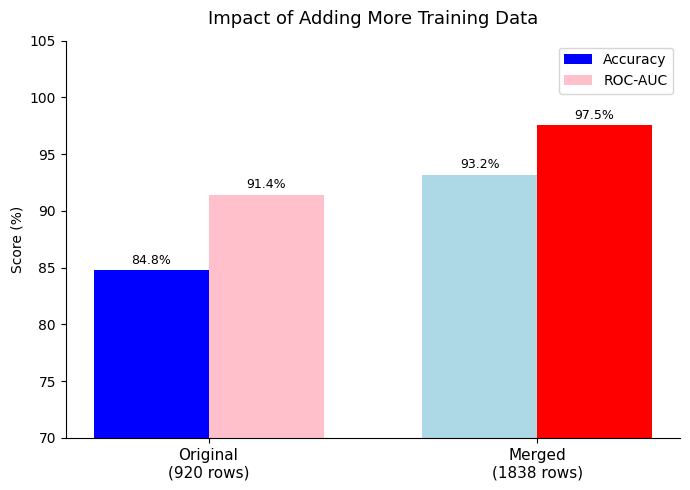

In [54]:
orig_acc = accuracy_score(y_test, best_rf.predict(x_test))
orig_auc = roc_auc_score(y_test, best_rf.predict_proba(x_test)[:, 1])
 
print(f"{'Accuracy':<20} {orig_acc*100:>19.2f}% {acc_merged*100:>19.2f}%")
print(f"{'ROC-AUC':<20} {orig_auc*100:>19.2f}% {auc_merged*100:>19.2f}%")
print(f"{'CV Score':<20} {'see earlier':>20} {cv_merged.mean()*100:>19.2f}%")
 
labels   = ["Original\n(920 rows)", f"Merged\n({len(df_merged)} rows)"]
acc_vals = [orig_acc * 100, acc_merged * 100]
auc_vals = [orig_auc * 100, auc_merged * 100]
 
x_pos = [0, 1]
width = 0.35
 
fig, ax = plt.subplots(figsize=(7, 5))
b1 = ax.bar([p - width/2 for p in x_pos], acc_vals, width,
            label="Accuracy", color=["blue", "lightblue"])
b2 = ax.bar([p + width/2 for p in x_pos], auc_vals, width,
            label="ROC-AUC",  color=["pink", "red"])
 
for bar in b1.patches + b2.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.1f}%",
        ha="center", va="bottom", fontsize=9
    )
 
ax.set_ylim(70, 105)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Score (%)")
ax.set_title("Impact of Adding More Training Data", fontsize=13, pad=12)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [55]:
if acc_merged > orig_acc:
    print(f"\n Merged model ({acc_merged*100:.2f}%) beats original ({orig_acc*100:.2f}%)")
    print("Saving merged model and new scaler...")
 
    with open("heart_disease_model.pkl", "wb") as f:
        pickle.dump(rf_merged, f)
 
    with open("scaler.pkl", "wb") as f:
        pickle.dump(scaler_merged, f)
 
    print("heart_disease_model.pkl → updated")
    print(" scaler.pkl             → updated")
    print("\n  Your Streamlit app will now use the merged model automatically.")
    print("   No changes needed in app.py.")
else:
    print(f"\nOriginal model ({orig_acc*100:.2f}%) still performs better.")
    print("Keeping original heart_disease_model.pkl and scaler.pkl unchanged.")


 Merged model (93.21%) beats original (84.78%)
Saving merged model and new scaler...
heart_disease_model.pkl → updated
 scaler.pkl             → updated

  Your Streamlit app will now use the merged model automatically.
   No changes needed in app.py.
